# Module 10 — Scaling and Efficiency (notebook)

Four short sections, all CPU-runnable:

1. **Per-rank memory breakdown** — what each ZeRO stage actually buys you, as a stacked bar plot.
2. **Activation checkpointing** — how much memory it saves, and at what FLOP cost.
3. **Chinchilla compute-optimal frontier** — the (params, tokens) curve as a function of compute budget. Where current frontier models sit on it.
4. **Activation checkpointing on a real tiny model** — measured activation memory on a small Qwen3-shape, before and after wrapping. Confirms the estimate.

Everything imports from [`efficiency.py`](efficiency.py).

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

from efficiency import (
    apply_activation_checkpointing,
    memory_breakdown,
    chinchilla_optimal,
    training_flops,
)

GB = 1024**3

## 1. Per-rank memory breakdown

A 1B-parameter model in BF16 mixed precision with AdamW. We show per-rank memory as we move from single GPU (no sharding) through ZeRO-1, -2, -3 on 8 ranks.

Each stage is cumulative: ZeRO-2 also shards optimizer state (ZeRO-1 did that), and so on. The plot shows where the bytes go and which bucket each stage drains.

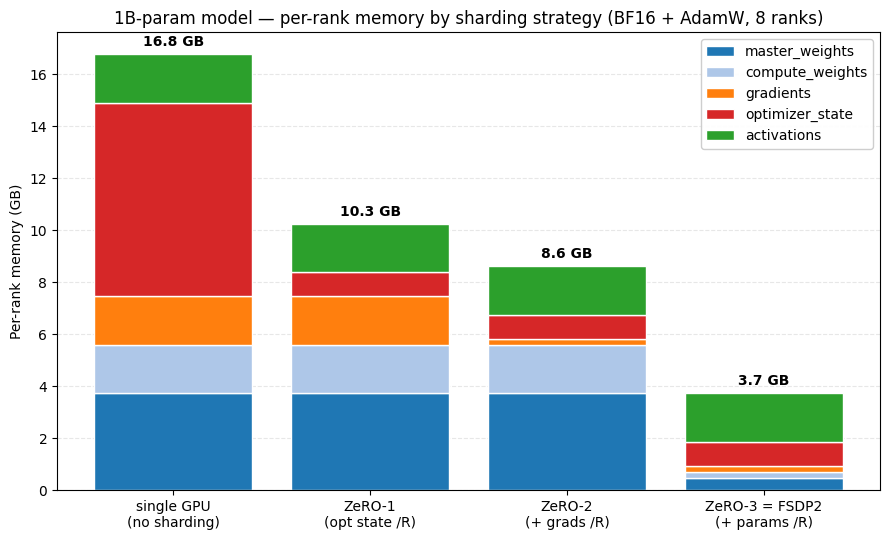


Key observation: activations don't shard (each rank computes its own).
Once you've gone to ZeRO-3, activations become the dominant term — that's
where activation checkpointing (next section) earns its keep.


In [2]:
N = 1e9            # 1B-param model
WORLD = 8          # 8-GPU node
GEOM = dict(n_layers=24, batch_size=1, seq_len=2048, d_model=2048)

scenarios = [
    ("single GPU\n(no sharding)", 0, 1),
    ("ZeRO-1\n(opt state /R)", 1, WORLD),
    ("ZeRO-2\n(+ grads /R)", 2, WORLD),
    ("ZeRO-3 = FSDP2\n(+ params /R)", 3, WORLD),
]

buckets = ["master_weights", "compute_weights", "gradients", "optimizer_state", "activations"]
colors = ["#1f77b4", "#aec7e8", "#ff7f0e", "#d62728", "#2ca02c"]

data = {b: [] for b in buckets}
totals = []
labels = []
for label, zs, ws in scenarios:
    b = memory_breakdown(n_params=N, dtype="bf16", optimizer="adamw",
                        zero_stage=zs, world_size=ws, **GEOM).as_dict()
    for k in buckets:
        data[k].append(b[k] / GB)
    totals.append(b["total"] / GB)
    labels.append(label)

fig, ax = plt.subplots(figsize=(9, 5.5))
bottoms = np.zeros(len(scenarios))
for bucket, color in zip(buckets, colors):
    vals = np.array(data[bucket])
    ax.bar(labels, vals, bottom=bottoms, color=color, label=bucket, edgecolor="white")
    bottoms = bottoms + vals

for i, t in enumerate(totals):
    ax.text(i, t + 0.3, f"{t:.1f} GB", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Per-rank memory (GB)")
ax.set_title("1B-param model — per-rank memory by sharding strategy (BF16 + AdamW, 8 ranks)")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("\nKey observation: activations don't shard (each rank computes its own).")
print("Once you've gone to ZeRO-3, activations become the dominant term — that's")
print("where activation checkpointing (next section) earns its keep.")

## 2. Activation checkpointing

Activations don't shard. With ZeRO-3 they become the biggest single bucket of memory. **Activation checkpointing** is the lever: drop ~99% of activation memory in exchange for ~33% extra FLOPs.

Below: same model as before, but at a more realistic long-context workload (batch 4, seq 4096). We compare `activation_checkpointing=False` (default) and `True`.

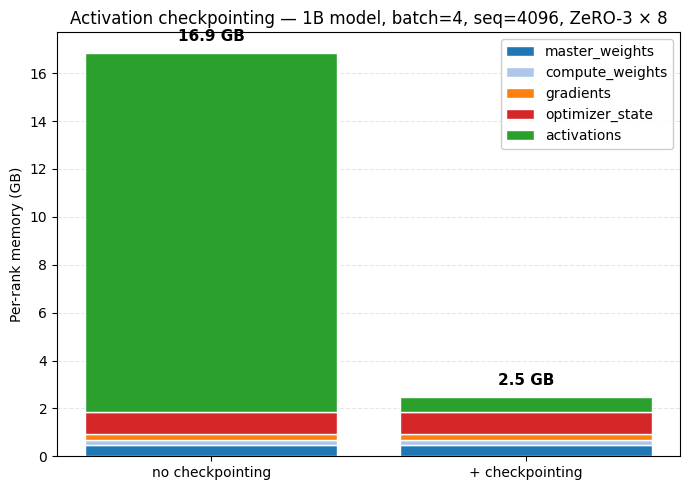


Activations: 15.0 GB → 0.62 GB  (24× reduction)
Cost: ~33% more FLOPs per step. Worth it whenever activations are limiting.


In [3]:
GEOM_LONG = dict(n_layers=24, batch_size=4, seq_len=4096, d_model=2048)

variants = []
for ac, label in [(False, "no checkpointing"), (True, "+ checkpointing")]:
    b = memory_breakdown(n_params=N, dtype="bf16", optimizer="adamw",
                        zero_stage=3, world_size=WORLD,
                        activation_checkpointing=ac, **GEOM_LONG).as_dict()
    variants.append((label, b))

fig, ax = plt.subplots(figsize=(7, 5))
labels = [v[0] for v in variants]
bottoms = np.zeros(len(variants))
for bucket, color in zip(buckets, colors):
    vals = np.array([v[1][bucket] / GB for v in variants])
    ax.bar(labels, vals, bottom=bottoms, color=color, label=bucket, edgecolor="white")
    bottoms = bottoms + vals

for i, (_, b) in enumerate(variants):
    ax.text(i, b["total"] / GB + 0.5, f"{b['total']/GB:.1f} GB",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Per-rank memory (GB)")
ax.set_title("Activation checkpointing — 1B model, batch=4, seq=4096, ZeRO-3 × 8")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

before = variants[0][1]["activations"] / GB
after = variants[1][1]["activations"] / GB
print(f"\nActivations: {before:.1f} GB → {after:.2f} GB  ({before/after:.0f}× reduction)")
print(f"Cost: ~33% more FLOPs per step. Worth it whenever activations are limiting.")

## 3. The Chinchilla compute-optimal frontier

Given a compute budget $C$, the 6ND approximation plus the 20:1 tokens-per-param ratio gives you the compute-optimal $(N^*, D^*)$ pair:

$$N^* = \sqrt{C \,/\, (6 \cdot 20)}, \qquad D^* = 20 \cdot N^*.$$

Below we plot the frontier across 7 orders of magnitude of compute. The named models are placed at *their actual training compute* — not at the frontier point — so you can see who trained Chinchilla-optimal and who deliberately did not.

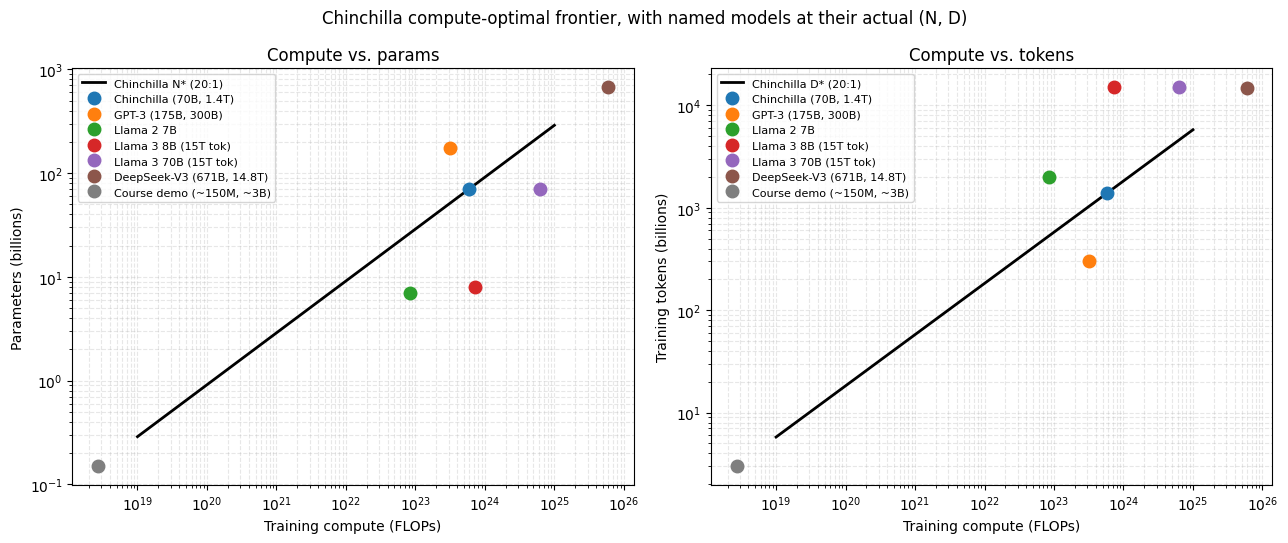


Reading the plot:
  - Llama 3 8B and 70B sit FAR ABOVE the D* line — they trained far past
    Chinchilla-optimal in tokens. Meta paid extra training FLOPs to get a
    smaller model that's cheaper to serve at inference. Deliberate choice.
  - Chinchilla and DeepSeek-V3 sit AT the curves — compute-optimal.
  - GPT-3 sits BELOW the D* line — undertrained by 2026 standards
    (the result that motivated the Chinchilla paper).


In [4]:
compute_grid = np.logspace(19, 25, 200)
N_star = np.array([chinchilla_optimal(c)[0] for c in compute_grid])
D_star = np.array([chinchilla_optimal(c)[1] for c in compute_grid])

# Known frontier models, plotted at their actual (N, D) — their FLOPs are 6ND.
known = [
    # (name, params, tokens, color)
    ("Chinchilla (70B, 1.4T)",  70e9, 1.4e12, "tab:blue"),
    ("GPT-3 (175B, 300B)",      175e9, 300e9, "tab:orange"),
    ("Llama 2 7B",                7e9, 2e12,  "tab:green"),
    ("Llama 3 8B (15T tok)",      8e9, 15e12, "tab:red"),
    ("Llama 3 70B (15T tok)",     70e9, 15e12, "tab:purple"),
    ("DeepSeek-V3 (671B, 14.8T)", 671e9, 14.8e12, "tab:brown"),
    ("Course demo (~150M, ~3B)",  150e6, 3e9,   "tab:gray"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: params (N) vs compute
ax = axes[0]
ax.loglog(compute_grid, N_star / 1e9, "-", color="black", lw=2, label="Chinchilla N* (20:1)")
for name, n, d, color in known:
    c = training_flops(n, d)
    ax.loglog(c, n / 1e9, "o", markersize=9, color=color, label=name)
ax.set_xlabel("Training compute (FLOPs)")
ax.set_ylabel("Parameters (billions)")
ax.set_title("Compute vs. params")
ax.grid(True, which="both", linestyle="--", alpha=0.3)
ax.legend(fontsize=8, loc="upper left")

# Right: tokens (D) vs compute
ax = axes[1]
ax.loglog(compute_grid, D_star / 1e9, "-", color="black", lw=2, label="Chinchilla D* (20:1)")
for name, n, d, color in known:
    c = training_flops(n, d)
    ax.loglog(c, d / 1e9, "o", markersize=9, color=color, label=name)
ax.set_xlabel("Training compute (FLOPs)")
ax.set_ylabel("Training tokens (billions)")
ax.set_title("Compute vs. tokens")
ax.grid(True, which="both", linestyle="--", alpha=0.3)
ax.legend(fontsize=8, loc="upper left")

plt.suptitle("Chinchilla compute-optimal frontier, with named models at their actual (N, D)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nReading the plot:")
print("  - Llama 3 8B and 70B sit FAR ABOVE the D* line — they trained far past")
print("    Chinchilla-optimal in tokens. Meta paid extra training FLOPs to get a")
print("    smaller model that's cheaper to serve at inference. Deliberate choice.")
print("  - Chinchilla and DeepSeek-V3 sit AT the curves — compute-optimal.")
print("  - GPT-3 sits BELOW the D* line — undertrained by 2026 standards")
print("    (the result that motivated the Chinchilla paper).")

## 4. Activation checkpointing on a real (tiny) model

The plots above use the closed-form estimate. Here we verify the *integration* on a real Qwen3 shape: that `apply_activation_checkpointing` actually wraps the decoder layers, and that forward + backward + a step of training still works under the wrap. The byte-level memory savings are best measured on GPU (Module 11 reports them on the real demo run); on CPU we settle for structural verification.

In [5]:
import torch
import torch.nn.functional as F
from transformers import Qwen3Config, Qwen3ForCausalLM


def make_tiny_qwen3(n_layers=4):
    cfg = Qwen3Config(
        vocab_size=2048,
        hidden_size=128,
        num_hidden_layers=n_layers,
        num_attention_heads=4,
        num_key_value_heads=2,
        intermediate_size=256,
        max_position_embeddings=256,
        tie_word_embeddings=True,
        attention_dropout=0.0,
        use_cache=False,
    )
    return Qwen3ForCausalLM(cfg)


def loss_fn(model, ids):
    logits = model(input_ids=ids, use_cache=False).logits
    return F.cross_entropy(
        logits[:, :-1].reshape(-1, logits.size(-1)),
        ids[:, 1:].reshape(-1),
    )


def count_checkpoint_wrappers(model):
    return sum(1 for m in model.modules()
               if type(m).__name__ == "CheckpointWrapper")


torch.manual_seed(0)
ids = torch.randint(0, 2000, (2, 64))

# Build two identical models — same seed → same init.
torch.manual_seed(42)
model_a = make_tiny_qwen3(n_layers=4).train()

torch.manual_seed(42)
model_b = make_tiny_qwen3(n_layers=4).train()
apply_activation_checkpointing(model_b)

print(f"Wrapper counts:")
print(f"  baseline    : {count_checkpoint_wrappers(model_a)} (expected 0)")
print(f"  checkpointed: {count_checkpoint_wrappers(model_b)} (expected 4 — one per decoder layer)")
print()

# Forward + backward on both — losses should match (same init, same data, deterministic).
loss_a = loss_fn(model_a, ids)
loss_a.backward()
gn_a = sum(p.grad.norm().item() for p in model_a.parameters() if p.grad is not None)

loss_b = loss_fn(model_b, ids)
loss_b.backward()
gn_b = sum(p.grad.norm().item() for p in model_b.parameters() if p.grad is not None)

print(f"Forward loss:")
print(f"  baseline    : {loss_a.item():.6f}")
print(f"  checkpointed: {loss_b.item():.6f}   (should match — recompute is exact)")
print()
print(f"Sum of grad norms after backward:")
print(f"  baseline    : {gn_a:.4f}")
print(f"  checkpointed: {gn_b:.4f}   (should match closely)")
print()
print("What this verifies:")
print("  - apply_activation_checkpointing wraps each decoder layer exactly once.")
print("  - Forward output is bit-identical (same init, same data, no dropout).")
print("  - Backward through the recompute path produces gradients within numerical")
print("    noise of the baseline. The wrap doesn't change what the model computes;")
print("    only what intermediate activations get saved between forward and backward.")
print()
print("The memory savings are what §1–2 estimated. They show up on GPU runs where")
print("you can read peak HBM usage via torch.cuda.max_memory_allocated().")

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wrapper counts:
  baseline    : 0 (expected 0)
  checkpointed: 4 (expected 4 — one per decoder layer)



Forward loss:
  baseline    : 7.646721
  checkpointed: 7.646721   (should match — recompute is exact)

Sum of grad norms after backward:
  baseline    : 12.5310
  checkpointed: 12.5310   (should match closely)

What this verifies:
  - apply_activation_checkpointing wraps each decoder layer exactly once.
  - Forward output is bit-identical (same init, same data, no dropout).
  - Backward through the recompute path produces gradients within numerical
    noise of the baseline. The wrap doesn't change what the model computes;
    only what intermediate activations get saved between forward and backward.

The memory savings are what §1–2 estimated. They show up on GPU runs where
you can read peak HBM usage via torch.cuda.max_memory_allocated().
